<a href="https://colab.research.google.com/github/kevinpolo2002/Notebooks_Agro_2026_1/blob/main/Calculo_caudal_maning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calculo de canales abiertos
# Curso: Fundamentos de Programación
# Docente: Justo
# Ingeniería Agroindustrial
# Grupo 3: Eider Rocha, Jesus Narvaez, Juan Mosquera, Valery Martinez, Breiner Viloria, Andrés Pino, Andrea Martinez, Kevin Polo, Farina Alvarez, Valerin Ruiz.

 #  Cálculo de Caudal en Canales Abiertos

## 1. Contexto del Proyecto y Fundamento Teórico
En la ingeniería agroindustrial y civil, el diseño de canales abiertos es fundamental para el manejo de distritos de riego, drenajes pluviales y conducción de fluidos. La velocidad y el volumen de agua que un canal puede transportar dependen directamente de su geometría, de la pendiente del terreno y de la rugosidad de las paredes del canal.

Para evaluar el comportamiento del flujo, utilizaremos la **Ecuación de Manning**, la cual se define matemáticamente mediante la siguiente expresión en sintaxis LaTeX:

$$Q = \frac{1}{n} \cdot A \cdot R_h^{2/3} \cdot S^{1/2}$$

### Definición de Variables:
* $Q$: Caudal o gasto volumétrico ($m^3/s$).
* $n$: Coeficiente de rugosidad de Manning (adimensional, depende del material del canal).
* $A$: Área de la sección transversal del flujo ($m^2$).
* $S$: Pendiente longitudinal del canal ($m/m$).
* $R_h$: Radio hidráulico ($m$), que se define como la relación entre el Área ($A$) y el Perímetro mojado ($P$):

$$R_h = \frac{A}{P}$$

---



In [9]:
import math

def calcular_geometria(tipo_canal, b, y, z=0):
    """
    Calcula el Área transversal (A) y el Perímetro mojado (P) de un canal.

    Parámetros:
    tipo_canal (str): "rectangular" o "trapezoidal".
    b (float): Ancho de la base del canal (m).
    y (float): Tirante o profundidad del agua (m).
    z (float): Relación de talud lateral (horizontal:vertical). Por defecto es 0.
    """
    # Convertimos a minúsculas para evitar errores por mayúsculas/minúsculas
    tipo = tipo_canal.lower()

    if tipo == "rectangular":
        area = b * y
        perimetro = b + (2 * y)

    elif tipo == "trapezoidal":
        area = (b + z * y) * y
        # Fórmula matemática: P = b + 2 * y * sqrt(1 + z^2)
        perimetro = b + 2 * y * math.sqrt(1 + z**2)

    else:
        print("Error: Tipo de canal no reconocido. Use 'rectangular' o 'trapezoidal'.")
        return None, None

    return area, perimetro



In [10]:
def calcular_caudal(A, P, n, S):
    """
    Calcula el caudal de un canal según la ecuación de Manning.

    Parámetros:
    A (float): Área transversal (m²).
    P (float): Perímetro mojado (m).
    n (float): Coeficiente de rugosidad de Manning.
    S (float): Pendiente del canal (m/m).
    """
    # Validación matemática para evitar división por cero en canales secos
    if P == 0:
        return 0.0

    # 1. Calcular el Radio Hidráulico (Rh = A / P)
    rh = A / P

    # 2. Aplicar la ecuación de Manning: Q = (1/n) * A * (Rh^(2/3)) * (S^(1/2))
    caudal = (1 / n) * A * (rh ** (2 / 3)) * (S ** (1 / 2))

    return caudal

In [11]:
# ==============================================================================
# CONFIGURACIÓN DE PARÁMETROS FIJOS (DATOS DE ENTRADA)
# ==============================================================================
b_base = 2.0         # Ancho de la base en metros
n_rugosidad = 0.015  # Concreto liso
S_pendiente = 0.001  # Pendiente del canal (m/m)
z_talud = 1.5        # Relación de talud para sección trapezoidal

# Lista de diferentes profundidades (tirantes) a evaluar
tirantes = [0.5, 1.0, 1.5, 2.0]

# ==============================================================================
# CICLO REPETITIVO E IMPRESIÓN DE REPORTE TÉCNICO
# ==============================================================================
print("==========================================================")
print("             REPORTE TÉCNICO DE CAPACIDAD DE FLUJO        ")
print("==========================================================")
print(f"{'Tirante (m)':<15} | {'Q Rectangular (m³/s)':<22} | {'Q Trapezoidal (m³/s)':<22}")
print("-" * 65)

# Iteración mediante ciclo for
for y in tirantes:
    # A. Evaluación de la sección Rectangular
    A_rect, P_rect = calcular_geometria("rectangular", b_base, y)
    Q_rect = calcular_caudal(A_rect, P_rect, n_rugosidad, S_pendiente)

    # B. Evaluación de la sección Trapezoidal (usa el talud z_talud)
    A_trap, P_trap = calcular_geometria("trapezoidal", b_base, y, z_talud)
    Q_trap = calcular_caudal(A_trap, P_trap, n_rugosidad, S_pendiente)

    # C. Impresión con formato alineado y 3 decimales de precisión
    print(f"{y:<15.1f} | {Q_rect:<22.3f} | {Q_trap:<22.3f}")

print("==========================================================")

             REPORTE TÉCNICO DE CAPACIDAD DE FLUJO        
Tirante (m)     | Q Rectangular (m³/s)   | Q Trapezoidal (m³/s)  
-----------------------------------------------------------------
0.5             | 1.014                  | 1.471                 
1.0             | 2.656                  | 5.390                 
1.5             | 4.499                  | 12.159                
2.0             | 6.435                  | 22.269                


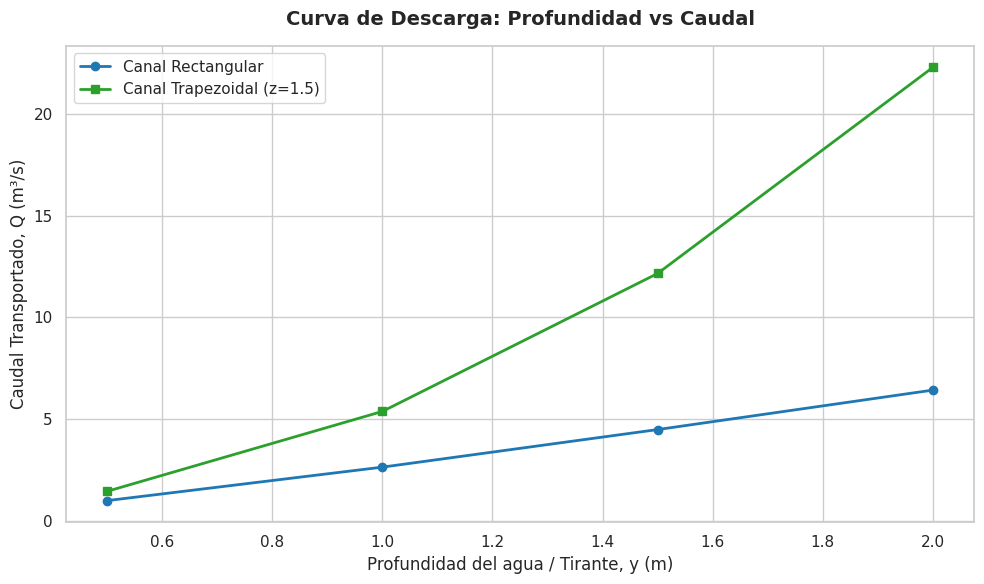

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. EL SALTO CONCEPTUAL: DE IMPRIMIR A ALMACENAR
# ==============================================================================
# Declaramos listas vacías antes del ciclo para guardar los resultados
caudales_rect = []
caudales_trap = []

# Volvemos a iterar para llenar nuestras listas usando .append()
for y in tirantes:
    # Cálculos geométricos e hidráulicos paso a paso
    A_rect, P_rect = calcular_geometria("rectangular", b_base, y)
    Q_rect = calcular_caudal(A_rect, P_rect, n_rugosidad, S_pendiente)

    A_trap, P_trap = calcular_geometria("trapezoidal", b_base, y, z_talud)
    Q_trap = calcular_caudal(A_trap, P_trap, n_rugosidad, S_pendiente)

    # Guardamos los resultados en sus respectivas listas
    caudales_rect.append(Q_rect)
    caudales_trap.append(Q_trap)

# ==============================================================================
# 2. VISUALIZACIÓN PROFESIONAL CON MATPLOTLIB Y SEABORN
# ==============================================================================
# Activamos el tema de cuadrícula de Seaborn para informes de ingeniería
sns.set_theme(style="whitegrid")

# Creamos la figura y definimos su tamaño
plt.figure(figsize=(10, 6))

# Graficamos la curva para el canal rectangular (Línea azul con marcadores circulares)
plt.plot(tirantes, caudales_rect, marker='o', linewidth=2, color='#1f77b4', label='Canal Rectangular')

# Graficamos la curva para el canal trapezoidal (Línea verde con marcadores cuadrados)
plt.plot(tirantes, caudales_trap, marker='s', linewidth=2, color='#2ca02c', label=f'Canal Trapezoidal (z={z_talud})')

# Personalización del gráfico con etiquetas técnicas e institucionales
plt.title('Curva de Descarga: Profundidad vs Caudal', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Profundidad del agua / Tirante, y (m)', fontsize=12)
plt.ylabel('Caudal Transportado, Q (m³/s)', fontsize=12)

# Añadimos la leyenda para identificar cada sección transversal
plt.legend(fontsize=11, loc='upper left')

# Optimizamos el espacio y mostramos el gráfico en el Notebook
plt.tight_layout()
plt.show()

## 2. Análisis de Resultados e Interpretación Ingenieril

### Pregunta de Reflexión para el Estudiante:
**¿Por qué la curva del canal trapezoidal crece mucho más rápido (de forma exponencial hacia arriba) que la del canal rectangular a medida que aumenta la profundidad del agua?**
Al observar la Curva de Descarga, se evidencia que ambas secciones transversales transportan un caudal similar cuando la profundidad del agua (tirante) es baja ($y = 0.5\text{ m}$). Sin embargo, a medida que el tirante aumenta, la curva del canal trapezoidal se despega exponencialmente hacia arriba en comparación con la del canal rectangular.Este comportamiento se debe a dos factores hidráulicos y geométricos fundamentales:Expansión geométrica del Área ($A$): En el canal rectangular, el ancho del espejo de agua es constante ($b = 2.0\text{ m}$), lo que significa que el área crece de forma estrictamente lineal respecto a la profundidad. En cambio, en el canal trapezoidal, las paredes inclinadas por la relación de talud ($z = 1.5$) permiten que el canal se ensanche lateralmente a medida que sube el nivel del agua. Esto genera un incremento geométrico notablemente mayor del área transversal disponible para el flujo.Eficiencia del Radio Hidráulico ($R_h$): Al expandirse lateralmente, el canal trapezoidal logra albergar un volumen de agua mucho mayor en relación con la superficie de las paredes con la que tiene contacto (Perímetro mojado, $P$). Al aumentar el Radio Hidráulico ($R_h = A/P$), se reduce la resistencia u oposición al flujo causada por la fricción viscosa contra las paredes de concreto.

---
**Conclusión ingenieril:** De acuerdo con la ecuación de Manning, al combinar un área transversal más grande con una menor fricción relativa (mayor $R_h$), la capacidad de transporte ($Q$) del canal trapezoidal se dispara de forma convexa. Esto demuestra visualmente por qué los canales trapezoidales son la opción de diseño más eficiente y segura en la ingeniería hidráulica para absorber crecientes pluviales repentinas y evitar desbordamientos en comparación con las secciones rectangulares.